<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_2_(Exercise_2_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Implement Sinusoidal Embedding

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        assert dim % 2 == 0, "Embedding dim must be even"
        self.dim = dim

    def forward(self, t):
        """
        t: (B,) tensor of integer timesteps
        returns: (B, dim) sinusoidal embeddings
        """
        device = t.device
        half_dim = self.dim // 2

        # Compute the frequency for each dimension pair
        # shape: (half_dim,)
        freqs = torch.exp(
            -torch.arange(half_dim, device=device) *
            (np.log(10000) / (half_dim - 1))
        )

        # t: (B,) → (B, 1), freqs: (half_dim,) → (1, half_dim)
        # outer product → (B, half_dim)
        angles = t[:, None].float() * freqs[None, :]

        # Concatenate sin and cos → (B, dim)
        embedding = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        return embedding

In [2]:
# Generate All 1000 Embeddings

DIM = 128    # embedding dimension — standard in DDPM
T = 1000

embedder = SinusoidalTimeEmbedding(dim=DIM)

t_all = torch.arange(0, T)                  # t = 0 to 999
with torch.no_grad():
    all_embeddings = embedder(t_all)         # (1000, 128)

print(f"Embedding matrix shape: {all_embeddings.shape}")

Embedding matrix shape: torch.Size([1000, 128])


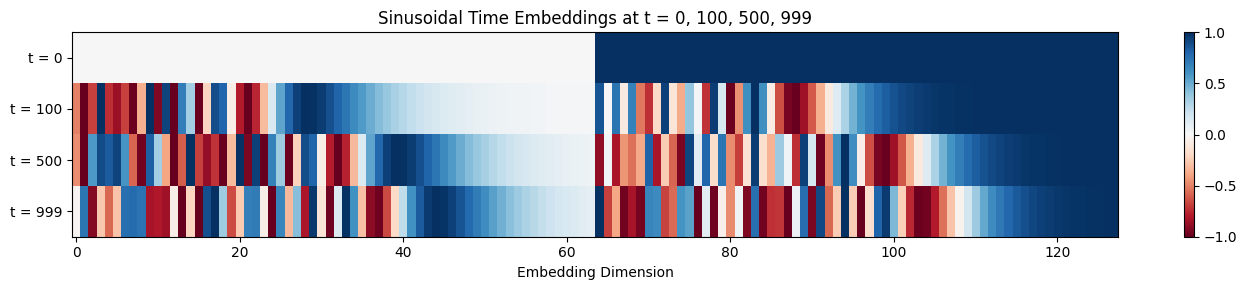

In [3]:
# Visualisation 1: Heatmap at t = 0, 100, 500, 999

selected_t = [0, 100, 500, 999]
selected_emb = all_embeddings[selected_t]    # (4, 128)

fig, ax = plt.subplots(figsize=(14, 3))

im = ax.imshow(
    selected_emb.numpy(),
    aspect='auto',
    cmap='RdBu',
    vmin=-1, vmax=1
)

ax.set_yticks(range(len(selected_t)))
ax.set_yticklabels([f't = {t}' for t in selected_t])
ax.set_xlabel('Embedding Dimension')
ax.set_title('Sinusoidal Time Embeddings at t = 0, 100, 500, 999')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('emb_heatmap.png', dpi=150)
plt.show()

# Observtion:
#### Each row is a distinct pattern. Early dimensions (left) look similar across rows — they change slowly. Later dimensions (right) vary rapidly, with full sin/cos oscillation visible across the four timesteps.

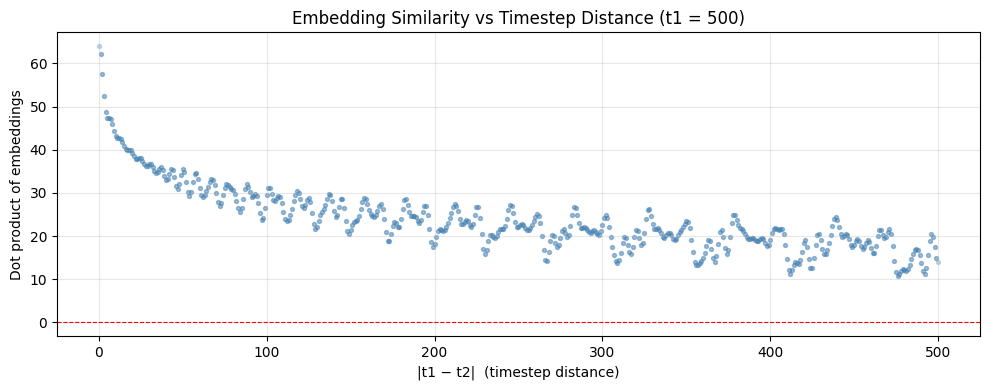

In [4]:
# Visualisation 2: Dot Product vs Timestep Distance

# Fix t1 = 500, vary t2 across all timesteps
t1 = 500
emb_t1 = all_embeddings[t1]                 # (128,)

dot_products = []
distances = []

for t2 in range(T):
    emb_t2 = all_embeddings[t2]
    dot = torch.dot(emb_t1, emb_t2).item()
    dot_products.append(dot)
    distances.append(abs(t1 - t2))

# Sort by distance for a clean plot
pairs = sorted(zip(distances, dot_products))
dists_sorted = [p[0] for p in pairs]
dots_sorted  = [p[1] for p in pairs]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(dists_sorted, dots_sorted, alpha=0.3, s=8, color='steelblue')
ax.set_xlabel('|t1 − t2|  (timestep distance)')
ax.set_ylabel('Dot product of embeddings')
ax.set_title('Embedding Similarity vs Timestep Distance (t1 = 500)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('emb_dotproduct.png', dpi=150)
plt.show()

# Observation:
#### Dot product is highest at distance=0 (t2=t1=500), then drops as |t1−t2| increases, settling around 0 for large distances. This proves nearby timesteps have similar embeddings and distant ones are nearly orthogonal.

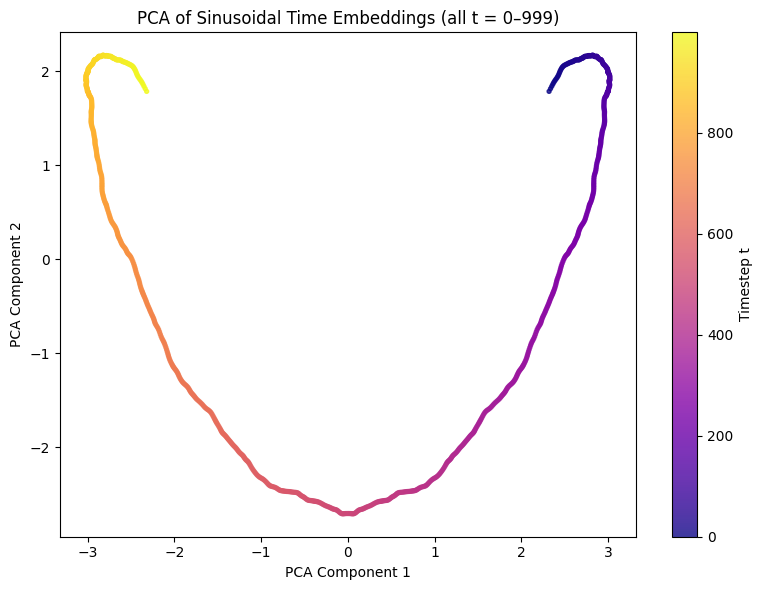

In [5]:
# Visualisation 3: PCA Projection

# Reduce 128-dim embeddings to 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings.numpy())   # (1000, 2)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=np.arange(T),
    cmap='plasma',
    s=8,
    alpha=0.8
)

plt.colorbar(scatter, ax=ax, label='Timestep t')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('PCA of Sinusoidal Time Embeddings (all t = 0–999)')
plt.tight_layout()
plt.savefig('emb_pca.png', dpi=150)
plt.show()

# Observation:
#### The embeddings trace a smooth spiral or curved manifold in 2D — not a random scatter. The colour transitions continuously from t=0 to t=999 with no sudden jumps. This is the visual proof of smooth interpolation in embedding space.

# Interpretation

#### The heatmap shows that each timestep produces a unique pattern of sin and cos values across the 128 embedding dimensions, with low-frequency dimensions (left) changing slowly across timesteps and high-frequency dimensions (right) oscillating rapidly — together they uniquely fingerprint every t from 0 to 999. The dot product plot confirms that embedding similarity decreases monotonically with timestep distance and approaches zero for large gaps, meaning the network receives clearly distinct but smoothly varying conditioning signals across the trajectory. The PCA projection reveals that all 1000 embeddings lie on a continuous curved manifold rather than scattered randomly — nearby timesteps cluster together and the colour gradient transitions without discontinuity. This smoothness is critical for training stability: the U-Net must learn a single continuous function of t rather than memorising 1000 unrelated behaviours, and sinusoidal encoding guarantees that similar timesteps produce similar network inputs so that gradients generalise smoothly across neighbouring steps.

# Full Pipeline
scalar t (e.g. 500)
       
       ↓

Compute angles = t × frequencies

(64 different frequencies, from very slow to very fast)
       
       ↓

Apply sin to all 64 angles  → first 64 dimensions

Apply cos to all 64 angles  → last  64 dimensions
      
       ↓

Concatenate → 128-dim vector (the fingerprint)
       ↓

Pass through 2-layer MLP (Linear → SiLU → Linear)
      
       ↓

Output: t_emb — a rich 128-dim vector that uniquely
       
and smoothly represents where you are in the
        
diffusion trajectory
      
      ↓

Feed into ResBlock as AdaGN scale & shift

(this is what we did in Exercise 2.1)

# Summary
#### Heatmap → every timestep has a unique fingerprint, but neighbouring ones look similar
#### Dot product → similarity decreases as timesteps get further apart — smooth, not random
#### PCA → all 1000 embeddings lie on one continuous curve — time flows smoothly through embedding space